<a href="https://colab.research.google.com/github/aciagala/pulsar-detection/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

train = pd.read_csv("data/raw/train.csv")
test  = pd.read_csv("data/raw/test.csv")

print(train.shape, test.shape)
print(train.dtypes)

(12528, 9) (5370, 9)
 Mean of the integrated profile                  float64
 Standard deviation of the integrated profile    float64
 Excess kurtosis of the integrated profile       float64
 Skewness of the integrated profile              float64
 Mean of the DM-SNR curve                        float64
 Standard deviation of the DM-SNR curve          float64
 Excess kurtosis of the DM-SNR curve             float64
 Skewness of the DM-SNR curve                    float64
target_class                                     float64
dtype: object


Brakujące wartości:

In [4]:
print(train.isnull().sum())
print(f"Missing: {train.isnull().mean().mul(100).round(2)}%")

 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64
Missing:  Mean of the integrated profile                   0.00
 Standard deviation of the integrated profile     0.00
 Excess kurtosis of the integrated profile       13.85
 Skewness of the integrated profile               0.00
 Mean of the DM-SNR curve                         0.00
 Standard deviation of the DM-SNR curve           9.40
 Excess kurtosis of the DM-SNR curve              0.00
 Skewness of the DM-SNR curve                     4.99
target_class                                      0.

Rozklad klas:

target_class
0.0    11375
1.0     1153
Name: count, dtype: int64
Pulsar ratio: 9.20%


<Axes: title={'center': 'Class Distribution'}, xlabel='target_class'>

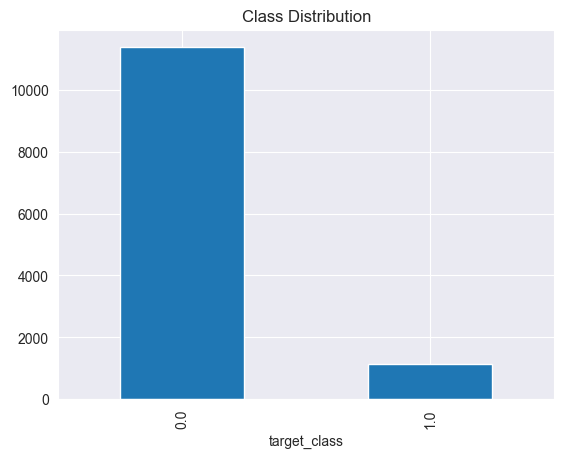

In [7]:
counts = train["target_class"].value_counts()
print(counts)
print(f"Pulsar ratio: {counts[1] / len(train):.2%}")

counts.plot(kind="bar", title="Class Distribution")

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Mean of the integrated profile,12528.0,111.041841,25.672828,5.812500,100.871094,115.183594,127.109375,189.734375
Standard deviation of the integrated profile,12528.0,46.521437,6.801077,24.772042,42.362222,46.931022,50.979103,91.808628
Excess kurtosis of the integrated profile,10793.0,0.478548,1.064708,-1.738021,0.024652,0.223678,0.473125,8.069522
Skewness of the integrated profile,12528.0,1.778431,6.208450,-1.791886,-0.188142,0.203317,0.932374,68.101622
Mean of the DM-SNR curve,12528.0,12.674758,29.613230,0.213211,1.910535,2.792642,5.413253,222.421405
Standard deviation of the DM-SNR curve,11350.0,26.351318,19.610842,7.370432,14.404353,18.412402,28.337418,110.642211
Excess kurtosis of the DM-SNR curve,12528.0,8.333489,4.535783,-3.139270,5.803063,8.451097,10.727927,34.539844
Skewness of the DM-SNR curve,11903.0,105.525779,107.399585,-1.976976,35.199899,83.126301,139.997850,1191.000837
target_class,12528.0,0.092034,0.289085,0.000000,0.000000,0.000000,0.000000,1.000000


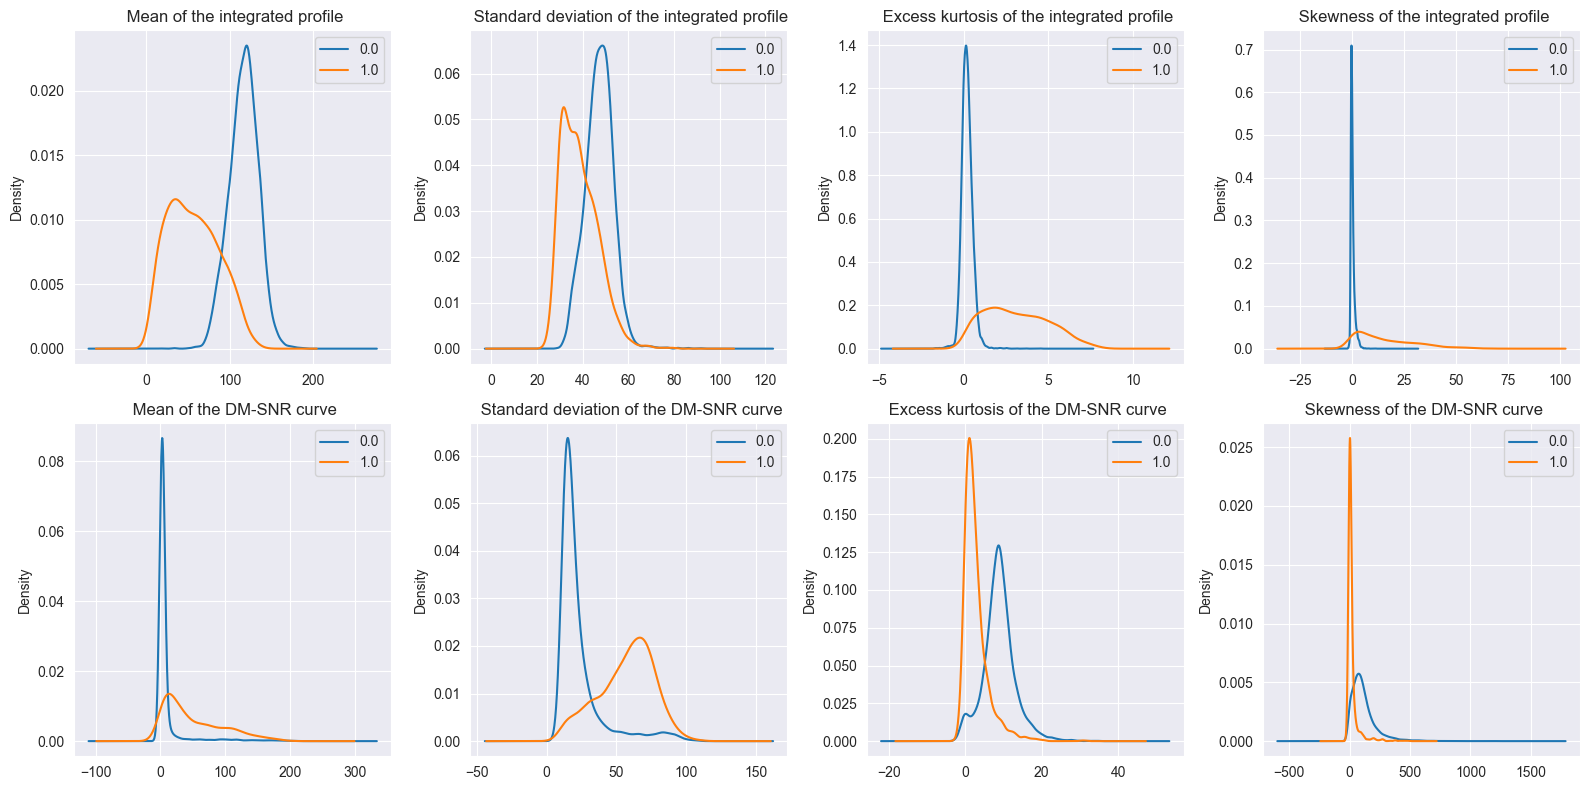

In [13]:
features = train.columns[:-1]  # all except "Class"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features):
    train.groupby("target_class")[col].plot(kind="kde", ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout()


outliers:

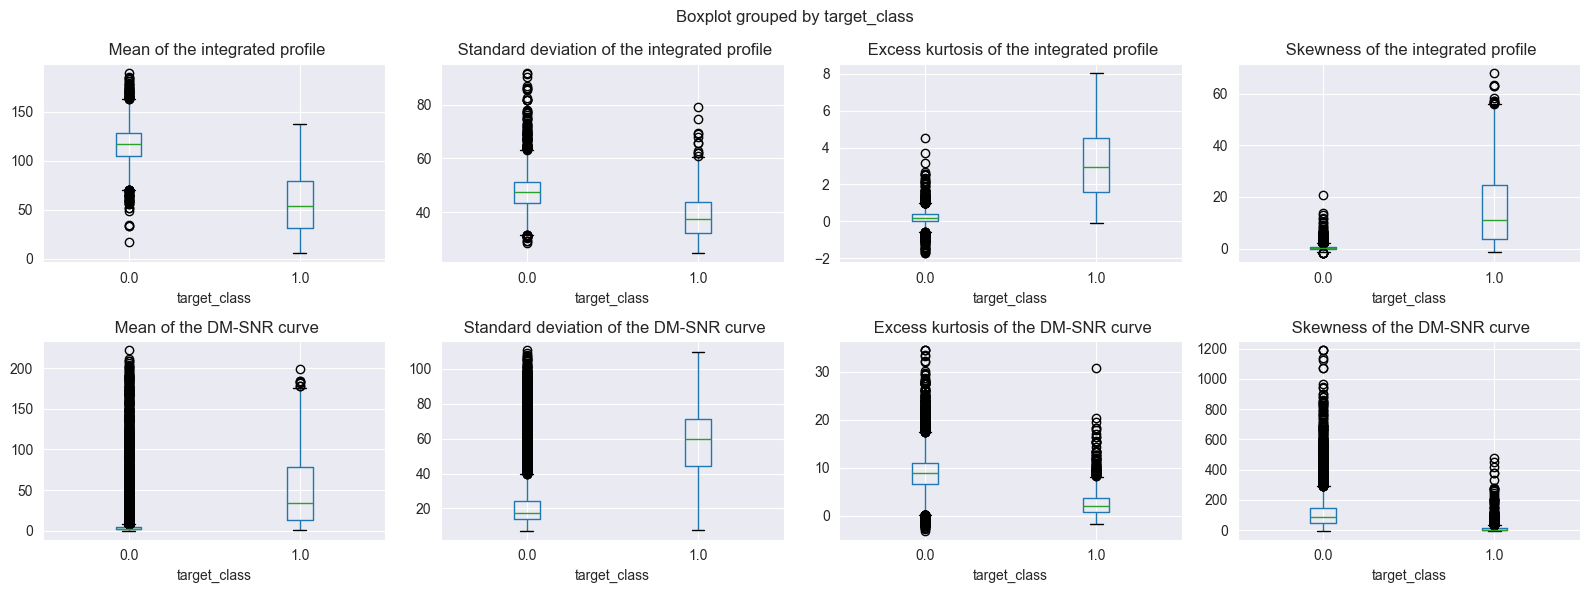

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flatten(), features):
    train.boxplot(column=col, by="target_class", ax=ax)
plt.tight_layout()

Text(0.5, 1.0, 'Feature Correlation Matrix')

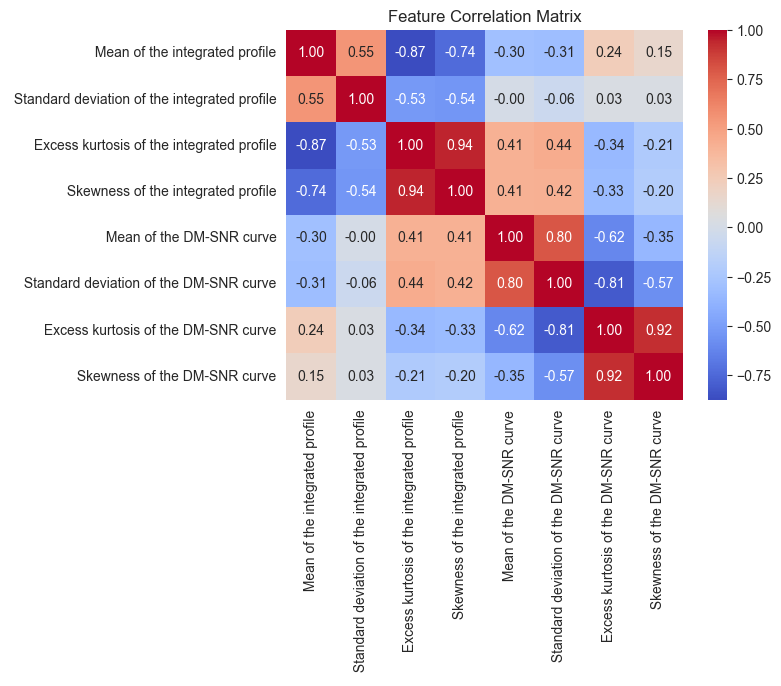

In [16]:
corr = train[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")

Text(0.5, 1.0, 'Correlation with Target')

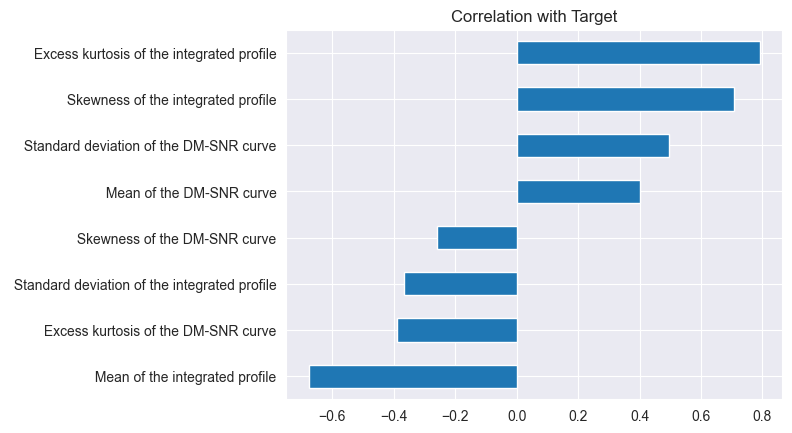

In [17]:
train.corr()["target_class"].drop("target_class").sort_values().plot(kind="barh")
plt.title("Correlation with Target")